In [23]:
import numpy as np
print(np.__version__)

2.4.6


In [24]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [25]:
# creating arrays or scientific computation.
import numpy as np
# ploting
import matplotlib.pyplot as plt
# split the data into training and testing.
from sklearn.model_selection import train_test_split
# substract the mean and normalise the data.
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
# chain the different layers together.
from tensorflow.keras.models import Sequential
# for fully connected dense neural network.
from tensorflow.keras.layers import Dense


In [26]:
# Function to generate Spiral Data

def generate_spiral_data(n_points, n_classes):
    X = []
    y = []
    for class_number in range(n_classes):
        ix = range(n_points * class_number, n_points * (class_number +1))
        r = np.linspace(0.0, 1, n_points)  # radius
        t = np.linspace(class_number * 4, (class_number + 1) * 4, n_points) + np.random.randn(n_points) * 0.2
        X.extend(np.c_[r * np.sin(t), r * np.cos(t)])
        y.extend([class_number] * n_points)
    return np.array(X), np.array(y)

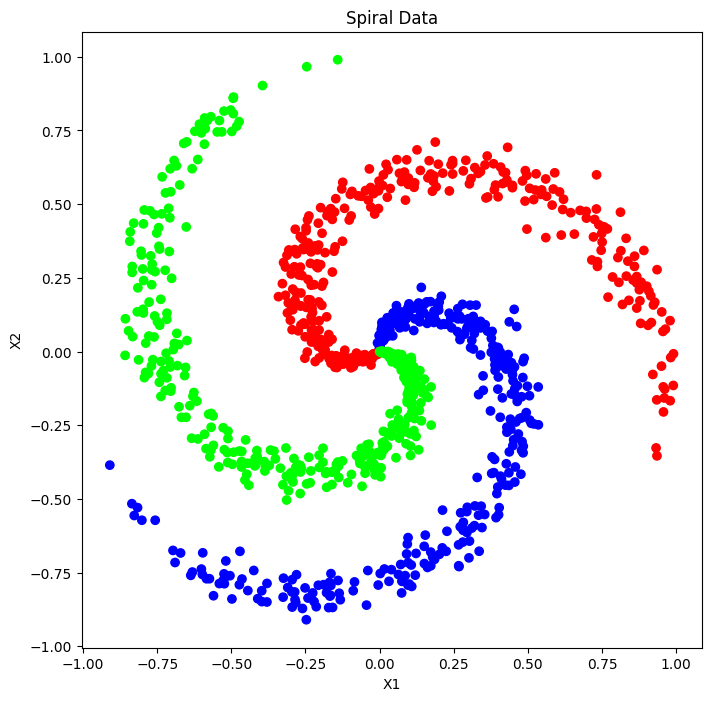

In [27]:
X, y = generate_spiral_data(333, 3)  # 999 points, 3 classes(red, green, blue) 3*333

plt.figure(figsize=(8,8))
plt.scatter(X[:,0], X[:,1], c=y, cmap='brg')
plt.title('Spiral Data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [28]:
X

array([[-0.00000000e+00,  0.00000000e+00],
       [ 9.02073989e-04,  2.87379485e-03],
       [ 6.53937059e-04,  5.98849761e-03],
       ...,
       [-4.92814883e-01,  8.63204256e-01],
       [-2.45752817e-01,  9.66224885e-01],
       [-1.41299499e-01,  9.89966894e-01]], shape=(999, 2))

In [29]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [30]:
# Split the data into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # random state help us to initialize the same way every single time.

# Initialize the Scaler
scaler = StandardScaler()

# Fit the scaler on the training data
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Define the model
model = Sequential()  # this tells keras we are defining the neural network and we are chain the different thing together.
model.add(Dense(64, input_dim=2, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))


e:\ML\NN\env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
# Compile the model

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])

In [32]:
# Fit the model

# this is also responsible for backpropagation. 
history = model.fit(x = X_train_scaled, y = y_train,
                    validation_data = (X_test_scaled, y_test),
                    epochs = 50, verbose=1)   # varbose 1 is responsible for displaying the training progress.

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4593 - loss: 1.0388 - val_accuracy: 0.5450 - val_loss: 0.9524
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5544 - loss: 0.9046 - val_accuracy: 0.5550 - val_loss: 0.8243
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5832 - loss: 0.7898 - val_accuracy: 0.5600 - val_loss: 0.7271
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6170 - loss: 0.7102 - val_accuracy: 0.5950 - val_loss: 0.6635
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6133 - loss: 0.6489 - val_accuracy: 0.6250 - val_loss: 0.6129
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6996 - loss: 0.5979 - val_accuracy: 0.6900 - val_loss: 0.5671
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7522 - loss: 0.5486 - val_accuracy: 0.7750 - val_loss: 0.5222
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8210 - loss: 0.5003 - val_accuracy: 0.8300 - val_loss:

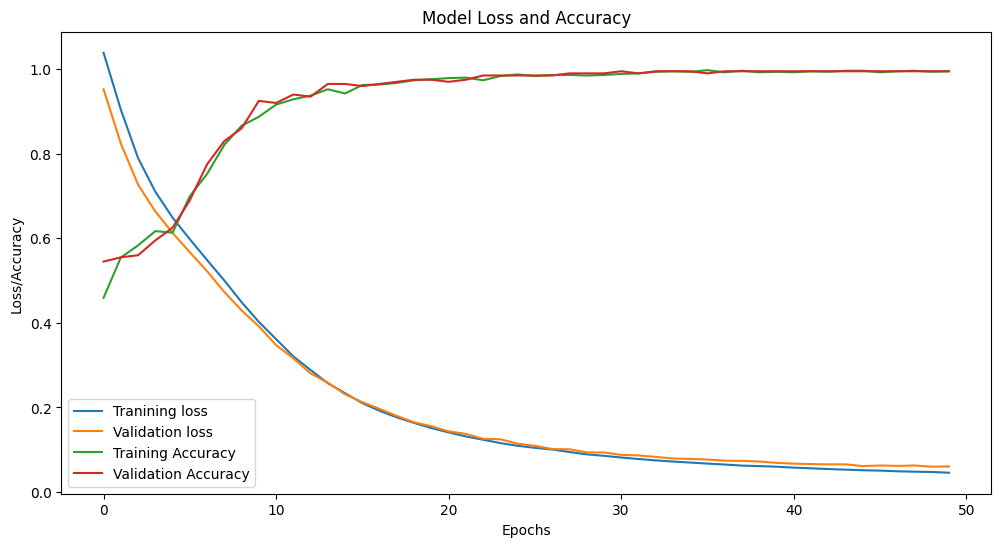

In [33]:
# plot the training History
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Tranining loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Loss and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


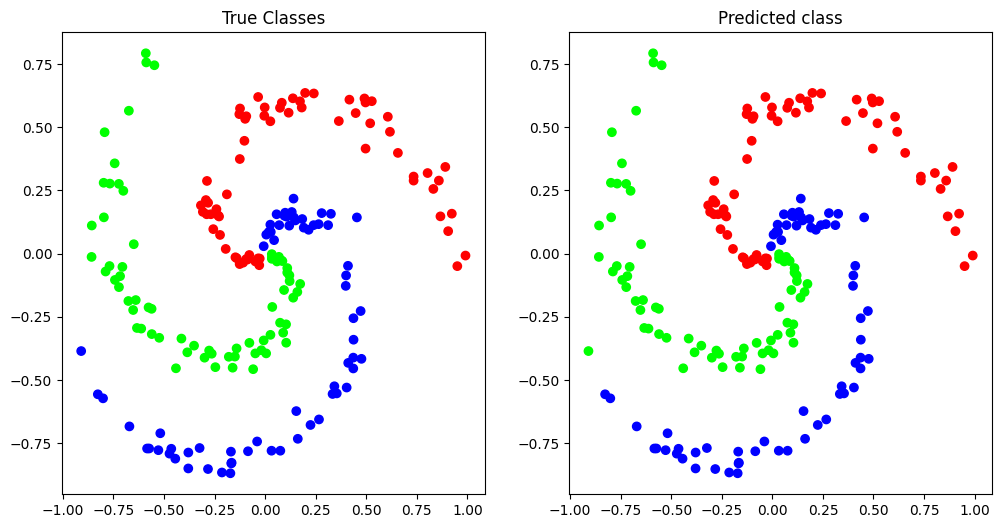

In [34]:
# predict the class for test data.
y_pred = np.argmax(model.predict(X_test_scaled), axis=1)

# Plot the comparison for predictions
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='brg')  # 'cmap = colormap that transition from blue to red to green'
plt.title('True Classes')
plt.subplot(1,2,2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='brg')
plt.title('Predicted class')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


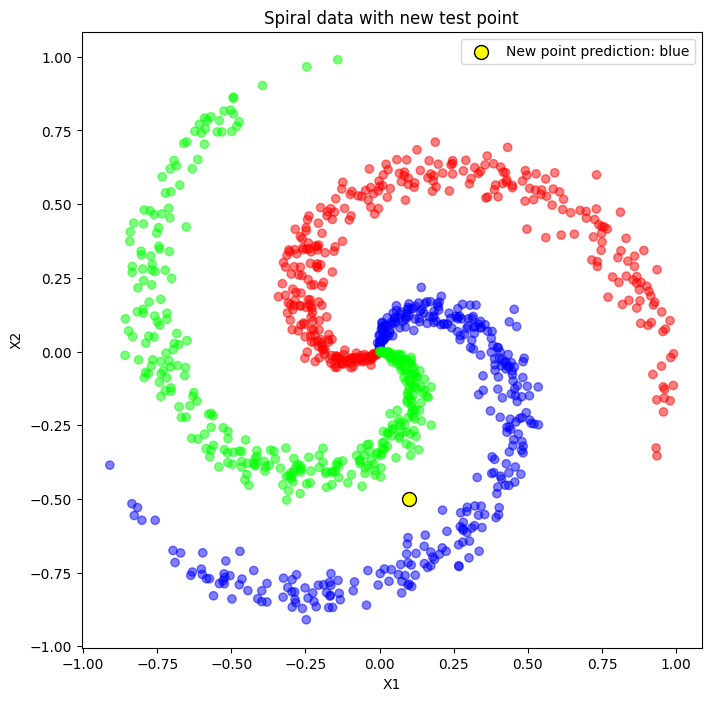

In [35]:
# New test point

new_point = np.array([[0.1, -0.5]])
new_point_scaled = scaler.transform(new_point)
new_pred = np.argmax(model.predict(new_point_scaled), axis=1)

# color map for legend
color_map = {0: 'red', 1: 'green', 2: 'blue'}

# plot the new test point prediction
plt.figure(figsize=(8,8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg', alpha=0.5)  # alpha=0.5 it is use for semi-transparent help overlap plotting.
plt.scatter(new_point[:, 0], new_point[:, 1], c='yellow', edgecolors='black', s = 100, label=f'New point prediction: {color_map[new_pred[0]]}')
plt.title('Spiral data with new test point')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()
